# A learned inverse for borehole shear velocity

*A `sonic_ml` walkthrough: from the fwap modal solver to a DL-FWI inverse net,
scored head-to-head against classical slowness-time processing.*

Borehole-acoustic inversion has the same shape as the protein-folding problem
that AlphaFold reframed: a slow, physics-based **forward** operator (here,
fwap's cylindrical-Biot modal solver mapping a formation to its guided-wave
dispersion) and an **inverse** we actually want (waveforms → formation
properties). `sonic_ml` learns that inverse directly from waveforms, closing
the gap where classical processing struggles — notably fast formations, where
the default two-mode gather carries no clean shear-head arrival.

This notebook runs the whole loop on a small synthetic dataset:

1. **Generate** a surrogate dataset from the fwap forward model.
2. **Load** it through the `.npz` contract into a `DatasetBundle`.
3. **Split** it by slow/fast regime.
4. **Score the classical baseline** — the reference to beat.
5. **Train** the DL-FWI inverse net.
6. **Compare** the two on identical held-out samples.
7. **Save** the trained model with a provenance *model card*.

Everything is synthetic and deliberately tiny so it runs end-to-end in well
under a minute; the closing section is explicit about what that does and does
not demonstrate.

## Setup

`sonic_ml`'s pure-NumPy *spine* (`import sonic_ml`) is torch-free; only
`sonic_ml.models` pulls in PyTorch. We import both here.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import sonic_ml
from sonic_ml import (
    default_geometry,
    gen_shim,
    load_npz,
    stratified_split,
)
from sonic_ml.baselines import ClassicalSTCBaseline
from sonic_ml.bench import evaluate, format_scorecard
from sonic_ml.determinism import seed_everything
from sonic_ml.models import (
    InversePredictor,
    parameter_mae,
    read_card,
    residual_zscore_std,
    save_with_card,
    train_inverse,
)
from sonic_ml.provenance import content_hash

seed_everything(0)
workdir = Path(tempfile.mkdtemp(prefix="sonic_ml_tutorial_"))
print("sonic_ml", sonic_ml.__version__, "| scratch:", workdir)

sonic_ml 0.0.1 | scratch: /tmp/sonic_ml_tutorial_tjdxodua


## 1. Generate a surrogate dataset

`gen_shim` bridges to the core generator
(`scripts/gen_surrogate_dataset.py`). For each random formation draw it runs
fwap's modal solver to get the per-mode dispersion curves (the label) and
synthesizes a multi-receiver waveform gather (the input). We keep the grid
coarse and the count small so the forward solves stay quick.

In [2]:
gen = gen_shim.generator()
freq = gen.default_freq_grid(n_freq=48)

N = 300
samples = gen_shim.generate(N, seed=0, freq=freq)

npz_path = workdir / "surrogate.npz"
gen_shim.save(str(npz_path), samples)
print(f"generated {len(samples)} samples -> {npz_path.name} "
      f"({npz_path.stat().st_size / 1e6:.1f} MB)")

generated 300 samples -> surrogate.npz (37.9 MB)


## 2. Load through the `.npz` contract

The `.npz` is the *only* hand-off between the (pure NumPy/SciPy) fwap data
generator and this ML layer. `load_npz` reads it defensively — refusing pickled
objects, checking the `schema_version`, and reading the sample/mode/frequency
counts from stored metadata rather than hard-coding them.

In [3]:
bundle = load_npz(str(npz_path))
geom = default_geometry(bundle)

print(f"samples N = {bundle.n_samples}")
print(f"modes   M = {bundle.n_modes}  {bundle.mode_names}")
print(f"freqs   F = {bundle.n_freq}")
print(f"params  P = {bundle.params.shape[1]}  {bundle.param_names}")
print(f"gather    = {bundle.gather.shape}  (N, receivers, samples)")
print(f"schema    = v{bundle.schema_version}")
print(f"geometry  = {geom.n_rec} receivers, dt = {geom.dt * 1e6:.0f} us")

vs, vf = bundle.param("vs"), bundle.param("vf")
n_slow = int((vs < vf).sum())
print(f"regimes   = {n_slow} slow (vs < vf), {bundle.n_samples - n_slow} fast")

samples N = 300
modes   M = 2  ('Stoneley', 'flexural')
freqs   F = 48
params  P = 6  ('vp', 'vs', 'rho', 'vf', 'rho_f', 'a')
gather    = (300, 8, 2048)  (N, receivers, samples)
schema    = v3
geometry  = 8 receivers, dt = 10 us
regimes   = 46 slow (vs < vf), 254 fast


## 3. Regime-stratified split

The default prior straddles the borehole-fluid velocity, so the dataset mixes
*slow* (`vs < vf`) and *fast* (`vs >= vf`) formations — two flexural regimes
with different dispersion physics. `stratified_split` partitions *within* each
regime so train / val / test carry the same slow/fast mix, and stores the exact
integer indices so the partition is reproducible.

In [4]:
split = stratified_split(bundle, seed=0)
for name, idx in [("train", split.train), ("val", split.val), ("test", split.test)]:
    lab = (bundle.param("vs")[idx] >= bundle.param("vf")[idx]).astype(int)
    print(f"{name:>5}: {idx.size:>3} samples  "
          f"({int((lab == 0).sum())} slow / {int((lab == 1).sum())} fast)")

train: 240 samples  (37 slow / 203 fast)
  val:  30 samples  (5 slow / 25 fast)
 test:  30 samples  (4 slow / 26 fast)


## 4. The classical baseline — the reference to beat

`ClassicalSTCBaseline` estimates Vs with fwap's slowness-time processing only
(no ML): dispersion-corrected STC over the dipole-flexural family for slow
formations, pseudo-Rayleigh STC for fast ones. It is a Vs `Predictor`, scored
by a model-agnostic harness that reports the median absolute error with a
bootstrap CI, split by regime.

Note the fast-regime error: the default two-mode (Stoneley + flexural) gather
has no clean pseudo-Rayleigh / shear-head arrival for a fast formation, so
classical fast-regime Vs recovery is weak — precisely the gap a learned inverse
is meant to close.

In [5]:
classical = ClassicalSTCBaseline()
classical_score = evaluate(classical, bundle, geom, indices=split.test, seed=0)
print(format_scorecard(classical_score))

Scorecard: classical_stc  (parameter: vs)
regime      n  finite     medAE    meanAE       95% CI (median)
---------------------------------------------------------------
   all     30      30     930.7     852.1           [690, 1088]
  slow      4       4      91.9      78.0             [14, 114]
  fast     26      26     984.2     971.2           [764, 1109]


## 5. Train the DL-FWI inverse net

`InverseNet` is a 1-D CNN over the multi-receiver gather (receivers as channels,
time as the convolved axis) with a **heteroscedastic** head: it predicts a mean
*and* a log-variance per parameter, trained with a Gaussian NLL, so weakly
identifiable parameters get calibrated error bars rather than false precision.
Crucially the input is the **gather only** — never the dispersion label — so the
net must learn the full waveform-to-parameters map.

trained 40 epochs; final train NLL = -0.386
active (varying) targets: ('vp', 'vs', 'rho', 'a')


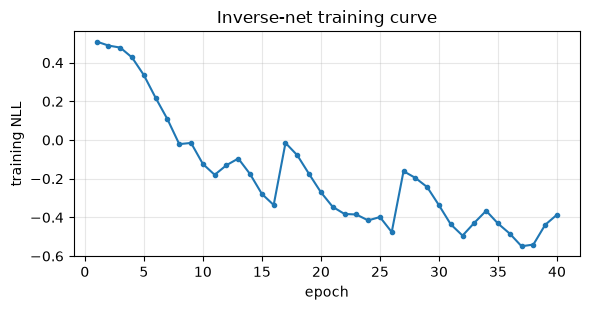

In [6]:
trained, history = train_inverse(
    bundle,
    split=split,
    epochs=40,
    batch_size=32,
    channels=(16, 32, 64),
    seed=0,
)
print(f"trained {len(history)} epochs; final train NLL = {history[-1]:.3f}")
print(f"active (varying) targets: {trained.active_names}")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(range(1, len(history) + 1), history, marker=".")
ax.set_xlabel("epoch")
ax.set_ylabel("training NLL")
ax.set_title("Inverse-net training curve")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Head-to-head on the held-out test set

`InversePredictor` adapts the trained net to the *same* `Predictor` protocol as
the classical baseline, so the harness scores both on identical samples.

In [7]:
inverse = InversePredictor(trained)
inverse_score = evaluate(inverse, bundle, geom, indices=split.test, seed=0)
print(format_scorecard(inverse_score))

print("\nMedian |Vs error| (m/s), classical vs inverse net:")
print(f"{'regime':>6}  {'classical':>10}  {'inverse':>10}  {'improvement':>12}")
for r in ("all", "slow", "fast"):
    c = classical_score.per_regime.get(r)
    i = inverse_score.per_regime.get(r)
    if c is None or i is None:
        continue
    factor = c.median_abs_error / i.median_abs_error if i.median_abs_error else float("nan")
    print(f"{r:>6}  {c.median_abs_error:>10.1f}  "
          f"{i.median_abs_error:>10.1f}  {factor:>11.1f}x")

Scorecard: inverse_net  (parameter: vs)
regime      n  finite     medAE    meanAE       95% CI (median)
---------------------------------------------------------------
   all     30      30      36.8      51.2              [18, 54]
  slow      4       4      34.3      29.8               [8, 42]
  fast     26      26      38.0      54.5              [18, 63]

Median |Vs error| (m/s), classical vs inverse net:
regime   classical     inverse   improvement
   all       930.7        36.8         25.3x
  slow        91.9        34.3          2.7x
  fast       984.2        38.0         25.9x


The cross-plot below shows predicted vs. true Vs on the test set, with the
per-parameter uncertainty the heteroscedastic head reports as error bars.

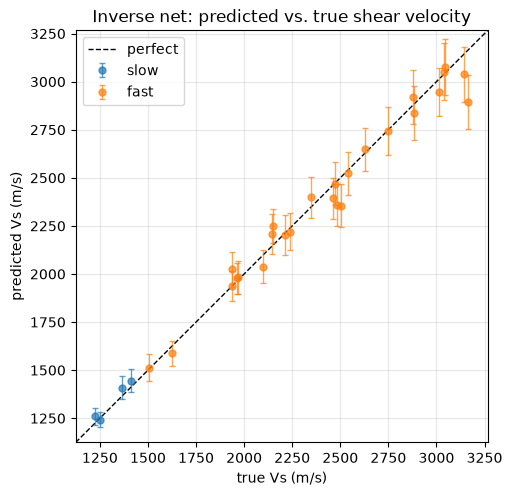

Vs residual z-score std = 0.67  (~1 is well-calibrated; >1 over-confident, <1 under-confident)


In [8]:
params_pred, params_std = trained.predict(bundle.gather[split.test])
vs_col = trained.active_names.index("vs")
vs_true = bundle.param("vs")[split.test]
vs_pred = params_pred[:, vs_col]
vs_err = params_std[:, vs_col]
is_fast = vs_true >= bundle.param("vf")[split.test]

fig, ax = plt.subplots(figsize=(5.2, 5.2))
lims = [min(vs_true.min(), vs_pred.min()) - 100,
        max(vs_true.max(), vs_pred.max()) + 100]
ax.plot(lims, lims, "k--", lw=1, label="perfect")
for mask, label, color in [(~is_fast, "slow", "tab:blue"),
                           (is_fast, "fast", "tab:orange")]:
    ax.errorbar(vs_true[mask], vs_pred[mask], yerr=vs_err[mask],
                fmt="o", ms=5, alpha=0.7, color=color, ecolor=color,
                elinewidth=1, capsize=2, label=label)
ax.set_xlabel("true Vs (m/s)")
ax.set_ylabel("predicted Vs (m/s)")
ax.set_title("Inverse net: predicted vs. true shear velocity")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

zstd = residual_zscore_std(trained, bundle, split.test, "vs")
print(f"Vs residual z-score std = {zstd:.2f}  "
      f"(~1 is well-calibrated; >1 over-confident, <1 under-confident)")

## 7. Save the model with a provenance card

A checkpoint's weights alone don't say *how it came to be*. Since the training
labels **are** fwap solver output, a changed physics engine silently re-labels
the data and invalidates any model trained on it. `save_with_card` writes the
weights-only-safe checkpoint **plus** a small JSON *model card* that binds it to
its provenance: the fwap version + git SHA, the hyper-parameters, the held-out
metrics, and the `content_hash` of the exact training dataset.

The large `.pt` is git-ignored; the small card is the committable record.

In [9]:
metrics = {
    "vs_mae_m_s": parameter_mae(trained, bundle, split.test, "vs"),
    "vs_median_ae_m_s": inverse_score.per_regime["all"].median_abs_error,
    "vs_residual_zstd": residual_zscore_std(trained, bundle, split.test, "vs"),
}
data_hash = content_hash(gen.stack_dataset(samples))

ckpt_path, card_path = save_with_card(
    trained,
    str(workdir / "inverse_net.pt"),
    metrics=metrics,
    data_content_hash=data_hash,
    note="sonic_ml tutorial notebook",
)
print(f"checkpoint -> {ckpt_path.name}  ({ckpt_path.stat().st_size / 1e3:.0f} kB)")
print(f"model card -> {card_path.name}\n")
print(read_card(str(ckpt_path)).to_json())

checkpoint -> inverse_net.pt  (122 kB)
model card -> inverse_net.pt.card.json

{
  "active_names": [
    "vp",
    "vs",
    "rho",
    "a"
  ],
  "data_content_hash": "1061637a06319885fcd0c60035176fe920c7a1c6fd43391602ae338c07efd9ca",
  "fwap_git_sha": "5ee9b9ef9e4e3bb523a76282c6486f1b9b5f6ec7",
  "fwap_version": "0.4.0",
  "hparams": {
    "channels": [
      16,
      32,
      64
    ],
    "dropout": 0.0,
    "hidden": 128,
    "kernel": 7,
    "n_rec": 8,
    "n_targets": 4
  },
  "metrics": {
    "vs_mae_m_s": 51.21832729020365,
    "vs_median_ae_m_s": 36.75231160598719,
    "vs_residual_zstd": 0.6660565938400393
  },
  "mode_names": null,
  "model_type": "TrainedInverseNet",
  "note": "sonic_ml tutorial notebook",
  "sonic_ml_version": "0.0.1"
}


## What this does and does not show

**Does:** a learned inverse trained purely on fwap's own forward model recovers
shear velocity roughly an order of magnitude more accurately than classical
slowness-time processing on the *same* held-out gathers — including the
fast-formation regime where the two-mode gather starves classical STC. The
uncertainty head gives per-sample error bars, and the model card ties the
weights back to the exact data and physics that produced them.

**Does not:** make any real-world deployment claim. Everything here is
synthetic — the net is scored on data drawn from the *same* forward model it was
trained on, so this measures the inverse's capacity, not its field accuracy. The
gap to real logs (noise, tool/borehole effects, mud, model error) is the hard
part. `sonic_ml` addresses pieces of it elsewhere: `GatherAugmentation` (M4a)
narrows the synthetic-to-real gap with training-time noise/amplitude
perturbations; the heteroscedastic head keeps weakly identifiable parameters
honest; and operator-learning surrogates (FNO/DeepONet) are the roadmap for the
cased-hole path. Treat this notebook as the *scaffolding* an AlphaFold-style
approach needs — a fast forward model, a learned inverse, and a benchmark that
scores them on equal footing — not as a finished field tool.